# Notebook 4 — Forecast Integration, Evaluation & Sensitivity Analysis
**Project:** Predicting Oil Well Output Using Hybrid DCA-LSTM  
**Well:** NO 15/9-F-14 H (Volve Oilfield, Norway)  
**Methodology ref:** §3.5.3 & §3.5.3.3 (Adefisan Peace Folashade, U22CS1009)

### Pre-requisite
Run notebooks **01**, **02**, and **03** first.

### Steps in this notebook
1. Load all pipeline artefacts
2. Compute evaluation metrics (RMSE, MAE, MAPE, R²) for all three models on test set
3. Production rate forecast comparison plot (§3.5.3.1)
4. Cumulative production comparison (§3.5.3.2)
5. Residual error distribution analysis (§3.5.3.4)
6. Performance metrics summary table (§3.5.3.3)
7. Sensitivity analysis — look-back window length
8. Export final results table to CSV

---

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf

SEED       = 42
np.random.seed(SEED)
OUTPUT_DIR = 'pipeline_outputs'
print('Imports loaded ✓')

Imports loaded ✓


## Step 1 — Load All Pipeline Artefacts

In [2]:
df_train = pd.read_csv(f'{OUTPUT_DIR}/f14h_train.csv', parse_dates=['Date'])
df_val   = pd.read_csv(f'{OUTPUT_DIR}/f14h_val.csv',   parse_dates=['Date'])
df_test  = pd.read_csv(f'{OUTPUT_DIR}/f14h_test.csv',  parse_dates=['Date'])
df_clean = pd.read_csv(f'{OUTPUT_DIR}/f14h_clean.csv', parse_dates=['Date'])

with open(f'{OUTPUT_DIR}/split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)

with open(f'{OUTPUT_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{OUTPUT_DIR}/dca_artefacts.pkl', 'rb') as f:
    dca = pickle.load(f)

with open(f'{OUTPUT_DIR}/prediction_artefacts.pkl', 'rb') as f:
    preds = pickle.load(f)

n_train = split_info['n_train']
n_val   = split_info['n_val']
n_test  = split_info['n_test']
n_total = split_info['n_total']

actual_all   = df_clean['OIL_PROD'].values
all_dates    = df_clean['Date'].values

# Unpack prediction artefacts
actual_te  = preds['actual_test_aligned']
hybrid_p   = preds['hybrid_pred']
dca_p      = preds['dca_pred']
solo_lstm  = preds['solo_lstm_pred']
n_pred     = preds['n_pred']
test_start = int(preds['pred_indices'][0])

# Test dates aligned with predictions
test_dates = all_dates[preds['pred_indices']]
print(f'Test set predictions loaded: {n_pred} months')
print(f'Test period : {pd.Timestamp(test_dates[0]).strftime("%Y-%m")} → '
      f'{pd.Timestamp(test_dates[-1]).strftime("%Y-%m")}')

Test set predictions loaded: 16 months
Test period : 2015-04 → 2016-07


## Step 2 — Evaluation Metrics (§3.5.3.3)
RMSE, MAE, MAPE, R² computed on the test set for all three models.

In [3]:
def mape(y_true, y_pred, eps=1.0):
    """Mean Absolute Percentage Error — skips points where y_true < eps."""
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  {label:<22}  RMSE={rmse:>10,.2f}  '
              f'MAE={mae:>10,.2f}  '
              f'MAPE={mape_val:>7.3f}%  '
              f'R²={r2:>8.4f}')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2}


print('Performance Evaluation — Test Set (Sm³/month):')
print('-' * 75)
m_dca    = compute_metrics(actual_te, dca_p,     'Standalone DCA')
m_lstm   = compute_metrics(actual_te, solo_lstm, 'Standalone LSTM')
m_hybrid = compute_metrics(actual_te, hybrid_p,  'Hybrid DCA-LSTM')
print('-' * 75)

# Percentage improvements of Hybrid over each baseline
print()
print('Hybrid DCA-LSTM improvement over Standalone DCA:')
for metric, baseline_val, hybrid_val in [
    ('RMSE', m_dca['RMSE'], m_hybrid['RMSE']),
    ('MAE',  m_dca['MAE'],  m_hybrid['MAE']),
    ('MAPE', m_dca['MAPE'], m_hybrid['MAPE']),
]:
    pct = (baseline_val - hybrid_val) / (baseline_val + 1e-8) * 100
    direction = 'improvement' if pct > 0 else 'degradation'
    print(f'  {metric:<6}: {pct:+.2f}% {direction}')

print()
print('Hybrid DCA-LSTM improvement over Standalone LSTM:')
for metric, baseline_val, hybrid_val in [
    ('RMSE', m_lstm['RMSE'], m_hybrid['RMSE']),
    ('MAE',  m_lstm['MAE'],  m_hybrid['MAE']),
    ('MAPE', m_lstm['MAPE'], m_hybrid['MAPE']),
]:
    pct = (baseline_val - hybrid_val) / (baseline_val + 1e-8) * 100
    direction = 'improvement' if pct > 0 else 'degradation'
    print(f'  {metric:<6}: {pct:+.2f}% {direction}')

Performance Evaluation — Test Set (Sm³/month):
---------------------------------------------------------------------------
  Standalone DCA          RMSE=  7,515.78  MAE=  7,503.86  MAPE=166.834%  R²=-25.9261
  Standalone LSTM         RMSE=  4,006.01  MAE=  3,972.63  MAPE= 90.572%  R²= -6.6498
  Hybrid DCA-LSTM         RMSE=    662.01  MAE=    579.96  MAPE= 13.795%  R²=  0.7911
---------------------------------------------------------------------------

Hybrid DCA-LSTM improvement over Standalone DCA:
  RMSE  : +91.19% improvement
  MAE   : +92.27% improvement
  MAPE  : +91.73% improvement

Hybrid DCA-LSTM improvement over Standalone LSTM:
  RMSE  : +83.47% improvement
  MAE   : +85.40% improvement
  MAPE  : +84.77% improvement


## Step 3 — Production Rate Forecast Comparison Plot (§3.5.3.4)

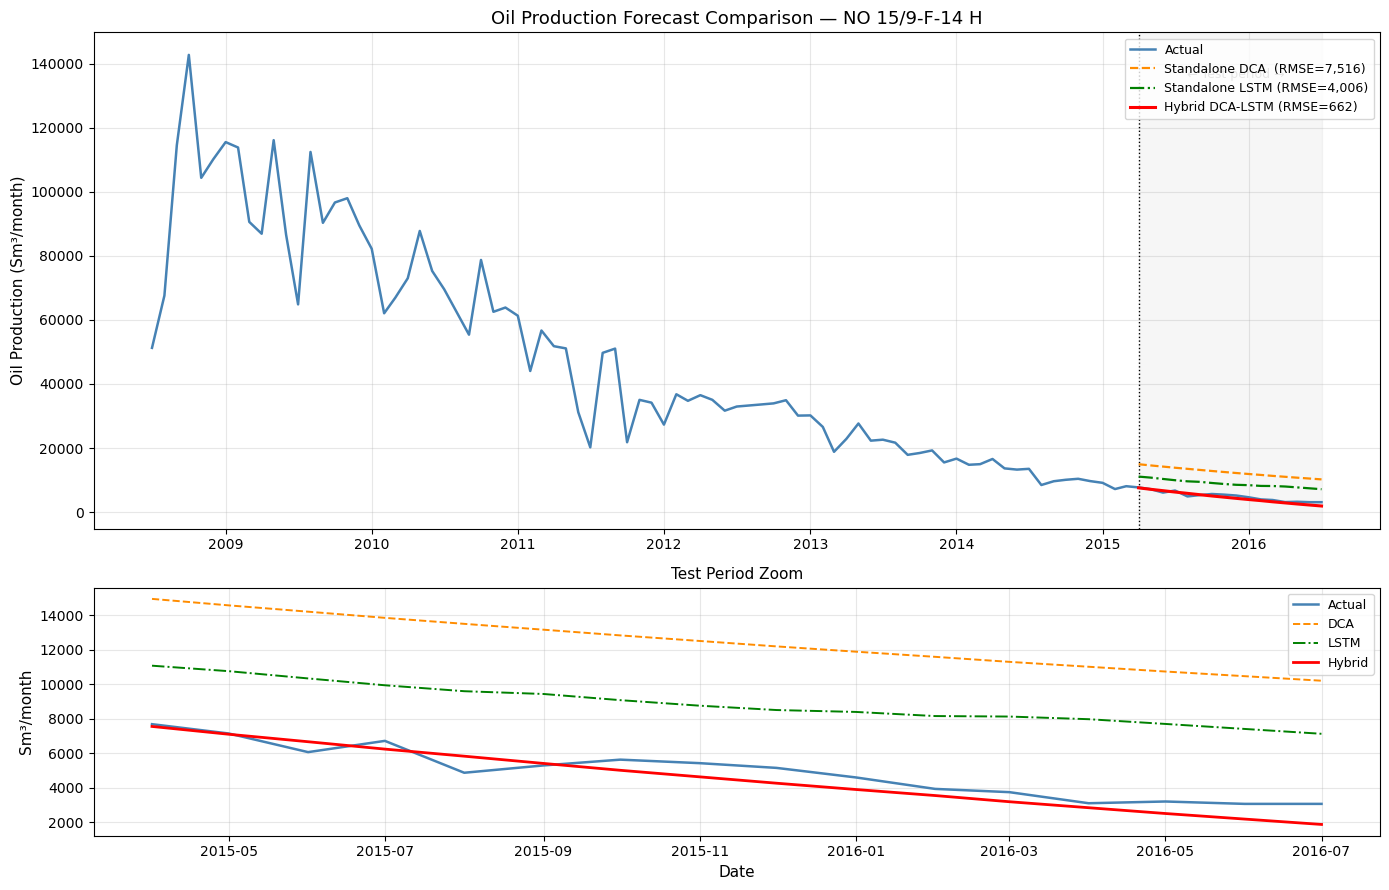

Saved: fig_10_forecast_comparison.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [2, 1]})

# ── Top panel: full history + forecasts ──────────────────────────────────────
ax = axes[0]
ax.plot(all_dates, actual_all, color='steelblue', lw=1.8, label='Actual', zorder=4)
ax.plot(test_dates, dca_p,    color='darkorange', lw=1.6, linestyle='--',
        label=f'Standalone DCA  (RMSE={m_dca["RMSE"]:,.0f})', zorder=3)
ax.plot(test_dates, solo_lstm,color='green',      lw=1.6, linestyle='-.',
        label=f'Standalone LSTM (RMSE={m_lstm["RMSE"]:,.0f})', zorder=3)
ax.plot(test_dates, hybrid_p, color='red',        lw=2.2,
        label=f'Hybrid DCA-LSTM (RMSE={m_hybrid["RMSE"]:,.0f})', zorder=5)

ax.axvspan(test_dates[0], test_dates[-1], alpha=0.07, color='gray')
ax.axvline(x=test_dates[0], color='black', linestyle=':', lw=1)
ax.annotate('← Test period →', xy=(test_dates[len(test_dates)//2], actual_all.max()*0.95),
            ha='center', fontsize=9, color='gray')

ax.set_title('Oil Production Forecast Comparison — NO 15/9-F-14 H', fontsize=13)
ax.set_ylabel('Oil Production (Sm³/month)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# ── Bottom panel: test period zoom ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(test_dates, actual_te,  color='steelblue', lw=1.8, label='Actual')
ax2.plot(test_dates, dca_p,      color='darkorange', lw=1.4, linestyle='--', label='DCA')
ax2.plot(test_dates, solo_lstm,  color='green',      lw=1.4, linestyle='-.', label='LSTM')
ax2.plot(test_dates, hybrid_p,   color='red',        lw=2.0, label='Hybrid')
ax2.set_title('Test Period Zoom', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Sm³/month', fontsize=11)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_10_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_10_forecast_comparison.png')

## Step 4 — Cumulative Production Forecast (§3.5.3.2)

Cumulative Production over Test Period (Sm³):
  Actual          :          78,804
  Standalone DCA  :         198,866  (error: +120,062)
  Standalone LSTM :         142,366  (error: +63,562)
  Hybrid DCA-LSTM :          72,876  (error: -5,929)


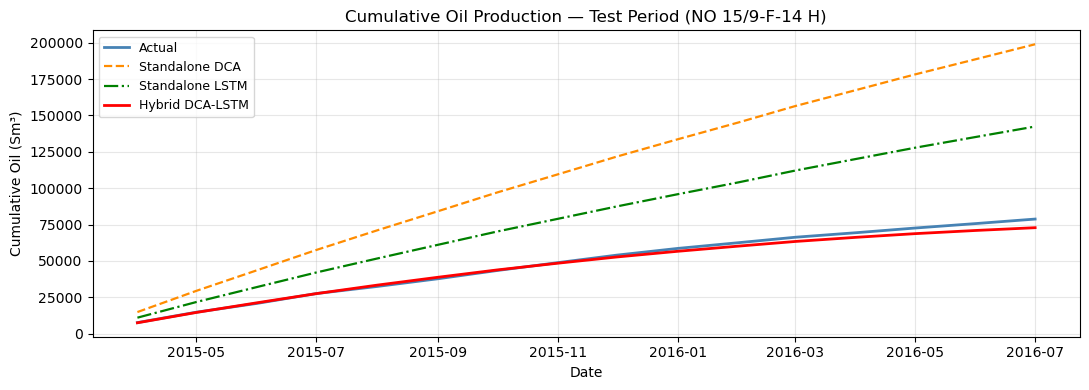

Saved: fig_11_cumulative.png


In [5]:
cum_actual = np.cumsum(actual_te)
cum_dca    = np.cumsum(dca_p)
cum_lstm   = np.cumsum(solo_lstm)
cum_hybrid = np.cumsum(hybrid_p)

print('Cumulative Production over Test Period (Sm³):')
print(f'  Actual          : {cum_actual[-1]:>15,.0f}')
print(f'  Standalone DCA  : {cum_dca[-1]:>15,.0f}  (error: {cum_dca[-1]-cum_actual[-1]:+,.0f})')
print(f'  Standalone LSTM : {cum_lstm[-1]:>15,.0f}  (error: {cum_lstm[-1]-cum_actual[-1]:+,.0f})')
print(f'  Hybrid DCA-LSTM : {cum_hybrid[-1]:>15,.0f}  (error: {cum_hybrid[-1]-cum_actual[-1]:+,.0f})')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_dates, cum_actual, color='steelblue',  lw=2,   label='Actual')
ax.plot(test_dates, cum_dca,    color='darkorange', lw=1.6, linestyle='--', label='Standalone DCA')
ax.plot(test_dates, cum_lstm,   color='green',      lw=1.6, linestyle='-.', label='Standalone LSTM')
ax.plot(test_dates, cum_hybrid, color='red',        lw=2,   label='Hybrid DCA-LSTM')
ax.set_title('Cumulative Oil Production — Test Period (NO 15/9-F-14 H)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Oil (Sm³)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_11_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_11_cumulative.png')

## Step 5 — Residual Error Distribution Analysis (§3.5.3.4)

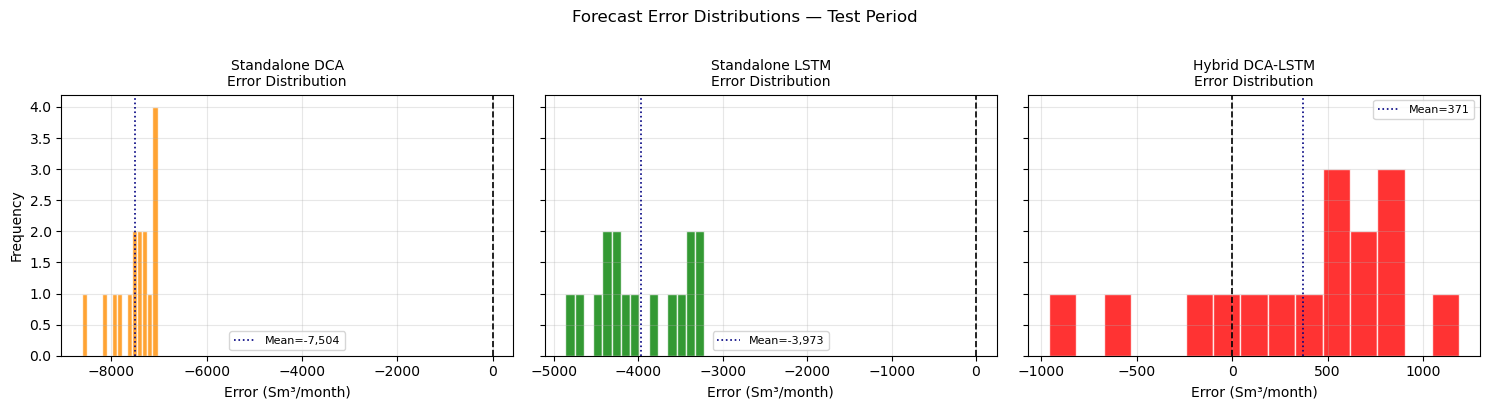

Saved: fig_12_error_distributions.png


In [6]:
err_dca    = actual_te - dca_p
err_lstm   = actual_te - solo_lstm
err_hybrid = actual_te - hybrid_p

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, errors, label, colour in [
    (axes[0], err_dca,    'Standalone DCA',  'darkorange'),
    (axes[1], err_lstm,   'Standalone LSTM', 'green'),
    (axes[2], err_hybrid, 'Hybrid DCA-LSTM', 'red'),
]:
    ax.hist(errors, bins=15, color=colour, edgecolor='white', alpha=0.8)
    ax.axvline(0,                  color='black', lw=1.2, linestyle='--')
    ax.axvline(errors.mean(),      color='navy',  lw=1.2, linestyle=':',
               label=f'Mean={errors.mean():,.0f}')
    ax.set_title(f'{label}\nError Distribution', fontsize=10)
    ax.set_xlabel('Error (Sm³/month)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Frequency')
plt.suptitle('Forecast Error Distributions — Test Period', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_12_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_12_error_distributions.png')

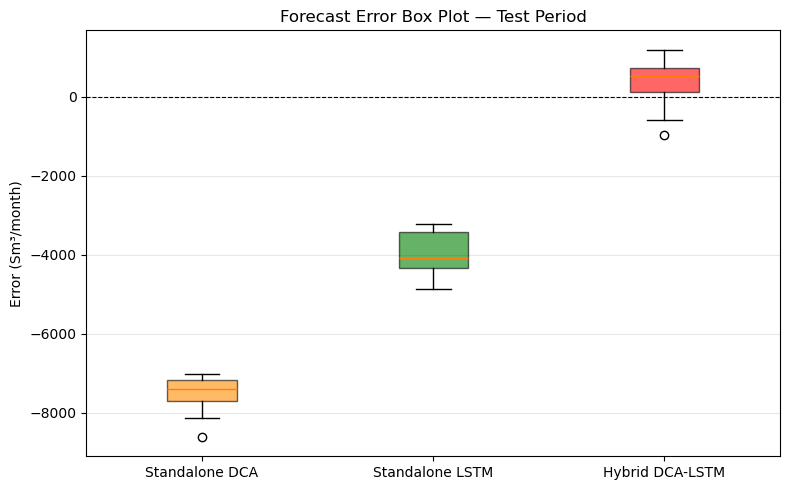

Saved: fig_13_error_boxplot.png


In [7]:
# Box plot comparison of errors across all three models
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [err_dca, err_lstm, err_hybrid],
    labels=['Standalone DCA', 'Standalone LSTM', 'Hybrid DCA-LSTM'],
    patch_artist=True,
    notch=False
)
colors_bp = ['darkorange', 'green', 'red']
for patch, colour in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(colour)
    patch.set_alpha(0.6)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Forecast Error Box Plot — Test Period', fontsize=12)
ax.set_ylabel('Error (Sm³/month)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_13_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_13_error_boxplot.png')

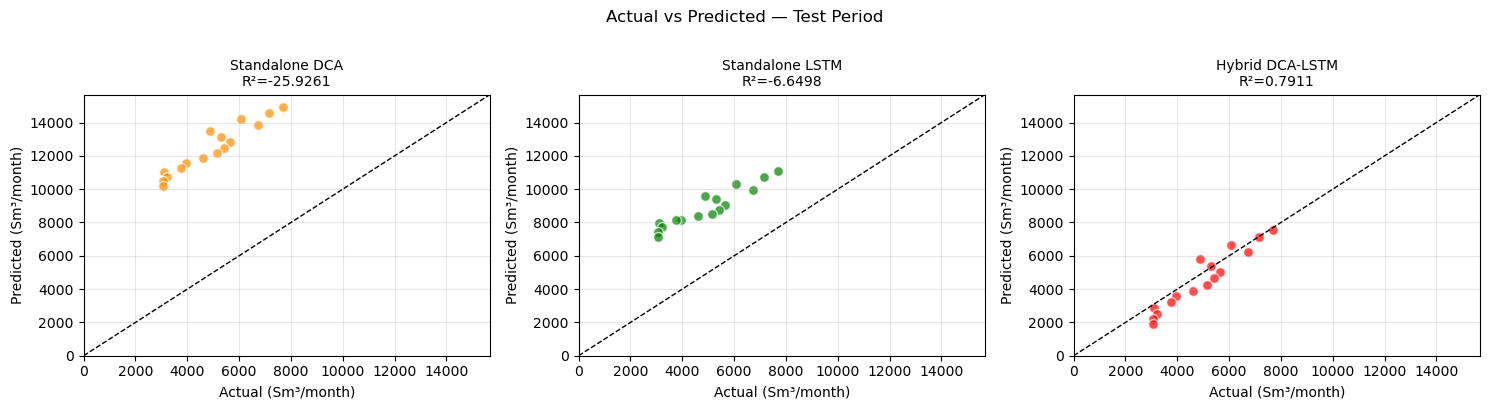

Saved: fig_14_actual_vs_pred_scatter.png


In [8]:
# Scatter: actual vs predicted
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
max_val = max(actual_te.max(), hybrid_p.max(), dca_p.max(), solo_lstm.max()) * 1.05

for ax, pred, label, colour in [
    (axes[0], dca_p,    'Standalone DCA',  'darkorange'),
    (axes[1], solo_lstm,'Standalone LSTM', 'green'),
    (axes[2], hybrid_p, 'Hybrid DCA-LSTM', 'red'),
]:
    ax.scatter(actual_te, pred, color=colour, alpha=0.7, edgecolor='white', s=50)
    ax.plot([0, max_val], [0, max_val], 'k--', lw=1)   # perfect-forecast line
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Actual (Sm³/month)')
    ax.set_ylabel('Predicted (Sm³/month)')
    r2_plot = r2_score(actual_te, pred)
    ax.set_title(f'{label}\nR²={r2_plot:.4f}', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted — Test Period', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_14_actual_vs_pred_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_14_actual_vs_pred_scatter.png')

## Step 6 — Training Loss Curves Side-by-Side

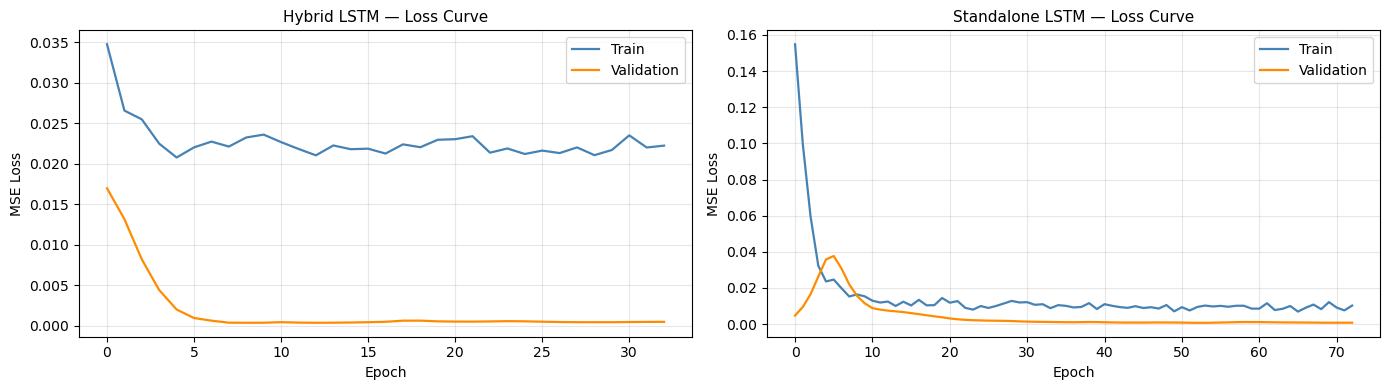

Saved: fig_15_loss_curves_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(preds['history_hybrid_loss'], color='steelblue',  lw=1.6, label='Train')
axes[0].plot(preds['history_hybrid_val'],  color='darkorange', lw=1.6, label='Validation')
axes[0].set_title('Hybrid LSTM — Loss Curve', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(preds['history_solo_loss'], color='steelblue',  lw=1.6, label='Train')
axes[1].plot(preds['history_solo_val'],  color='darkorange', lw=1.6, label='Validation')
axes[1].set_title('Standalone LSTM — Loss Curve', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_15_loss_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_15_loss_curves_comparison.png')

## Step 7 — Sensitivity Analysis: Look-Back Window Length

Re-load the hybrid LSTM model and evaluate predictions at different lookback windows.

> **Note:** this section evaluates look-back window length only, at the original
> default horizon. For the complete, properly-validated grid search over BOTH
> look-back window (W) AND forecast horizon (T) — which resolves the thesis's
> documented inconsistency between the methodology chapter's promised grid
> (§3.2.4) and the results chapter's reported configuration (§4.3) — see
> **`02b_Grid_Search.ipynb`**. For the full three-axis sensitivity analysis
> promised in §3.2.9 (training data length, DCA functional form, and LSTM
> architectural depth, not just look-back window), see
> **`03b_Sensitivity_Analysis.ipynb`**. The cells below are retained for
> continuity with the original notebook structure but should not be treated
> as the complete sensitivity analysis on their own.


In [10]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

with open(f'{OUTPUT_DIR}/dca_artefacts.pkl', 'rb') as f:
    dca = pickle.load(f)

actual_all    = df_clean['OIL_PROD'].values
trend_full    = dca['trend_full']
residuals_all = dca['residuals_all']
oil_norm      = scaler.transform(actual_all.reshape(-1, 1)).flatten()
trend_norm    = scaler.transform(trend_full.reshape(-1, 1)).flatten()
res_abs_max   = np.abs(residuals_all[:n_train]).max()
res_norm      = residuals_all / (res_abs_max + 1e-8)
q0_feat       = np.full(n_total, dca['q0'] / (actual_all[:n_train].max() + 1e-8))
Di_feat       = np.full(n_total, float(np.clip(dca['Di'], 0, 1)))
b_feat        = np.full(n_total, dca['b'])
X_full        = np.column_stack([oil_norm, trend_norm, res_norm,
                                  q0_feat, Di_feat, b_feat])

def create_windows(X, y, lookback, horizon=1):
    Xw, yw = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xw.append(X[i:i+lookback])
        yw.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xw), np.array(yw)

def build_lstm(lookback, n_features, horizon=1, u1=64, u2=32,
               d1=0.2, d2=0.2, lr=0.001):
    m = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(u1, return_sequences=True), Dropout(d1),
        LSTM(u2, return_sequences=False), Dropout(d2),
        Dense(horizon)
    ])
    m.compile(optimizer=Adam(lr), loss='mse')
    return m


lookback_sens = {}

for W in [6, 9, 12, 18]:
    Xw, yw = create_windows(X_full, res_norm, W)
    n_tr_w = max(1, n_train - W)
    n_va_w = n_val

    X_tr = Xw[:n_tr_w]
    y_tr = yw[:n_tr_w]
    X_va = Xw[n_tr_w : n_tr_w + n_va_w]
    y_va = yw[n_tr_w : n_tr_w + n_va_w]
    X_te = Xw[n_tr_w + n_va_w:]
    y_te = yw[n_tr_w + n_va_w:]

    if len(X_tr) < 2 or len(X_va) < 1 or len(X_te) < 1:
        print(f'  W={W:>2}: insufficient windows — skipped.')
        continue

    tf.random.set_seed(SEED)
    m = build_lstm(W, X_full.shape[1])
    m.fit(X_tr, y_tr,
          validation_data=(X_va, y_va),
          epochs=150, batch_size=16,
          callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
          verbose=0)

    rp = m.predict(X_te, verbose=0).flatten()
    rp_orig = rp * (res_abs_max + 1e-8)

    # ── Correct index alignment (same fix as Notebook 3) ──────────────────
    n_test_windows_w = len(rp_orig)
    pred_idx_w = np.arange(n_train + n_val + W,
                            n_train + n_val + W + n_test_windows_w)

    # Clip to valid array bounds
    pred_idx_w = pred_idx_w[pred_idx_w < n_total]
    n_valid    = len(pred_idx_w)

    if n_valid == 0:
        print(f'  W={W:>2}: no valid prediction indices — skipped.')
        continue

    rp_orig_w    = rp_orig[:n_valid]
    trend_te_w   = trend_full[pred_idx_w]
    actual_te_w  = actual_all[pred_idx_w]
    hyb          = np.clip(trend_te_w + rp_orig_w, 0, None)

    n_use = min(len(actual_te_w), len(hyb))
    if n_use < 2:
        print(f'  W={W:>2}: too few points for metrics — skipped.')
        continue

    rmse_w = np.sqrt(mean_squared_error(actual_te_w[:n_use], hyb[:n_use]))
    r2_w   = r2_score(actual_te_w[:n_use], hyb[:n_use])
    lookback_sens[W] = {'RMSE': rmse_w, 'R2': r2_w}
    print(f'  W={W:>2}  RMSE={rmse_w:>10,.2f}  R²={r2_w:.4f}')

print()
print('Look-back sensitivity complete ✓')

  W= 6  RMSE=    584.63  R²=0.6407
  W= 9  RMSE=    495.69  R²=0.1676
  W=12  RMSE=    362.68  R²=-40.3037
  W=18: no valid prediction indices — skipped.

Look-back sensitivity complete ✓


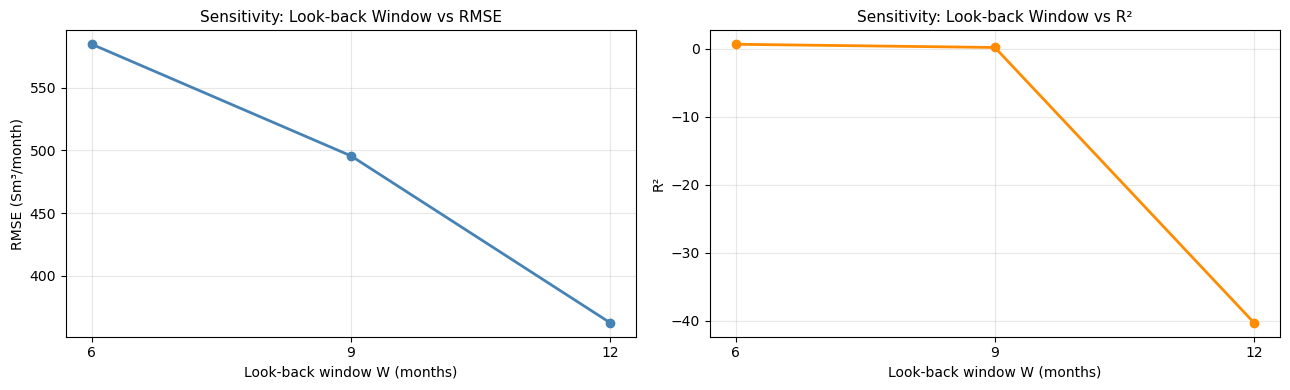

Saved: fig_16_lookback_sensitivity.png


In [11]:
# Sensitivity plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if lookback_sens:
    ws    = sorted(lookback_sens.keys())
    rmses = [lookback_sens[w]['RMSE'] for w in ws]
    r2s   = [lookback_sens[w]['R2']   for w in ws]

    axes[0].plot([str(w) for w in ws], rmses, marker='o', color='steelblue', lw=2)
    axes[0].set_title('Sensitivity: Look-back Window vs RMSE', fontsize=11)
    axes[0].set_xlabel('Look-back window W (months)')
    axes[0].set_ylabel('RMSE (Sm³/month)')
    axes[0].grid(alpha=0.3)

    axes[1].plot([str(w) for w in ws], r2s, marker='o', color='darkorange', lw=2)
    axes[1].set_title('Sensitivity: Look-back Window vs R²', fontsize=11)
    axes[1].set_xlabel('Look-back window W (months)')
    axes[1].set_ylabel('R²')
    axes[1].grid(alpha=0.3)
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Insufficient data for sensitivity',
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_16_lookback_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_16_lookback_sensitivity.png')

## Step 8 — Final Summary Table & CSV Export

In [12]:
results_df = pd.DataFrame([m_dca, m_lstm, m_hybrid])
results_df = results_df.round({'RMSE': 2, 'MAE': 2, 'MAPE': 4, 'R2': 6})
results_df.to_csv(f'{OUTPUT_DIR}/final_results.csv', index=False)

print('='*72)
print('  FINAL PERFORMANCE METRICS SUMMARY — NO 15/9-F-14 H (Test Set)')
print('='*72)
print(results_df.to_string(index=False))
print()

# DCA parameter summary
print('DCA Parameters (Hyperbolic Arps, §3.2.3):')
print(f'  q₀  = {dca["q0"]:>15,.4f} Sm³/month  (initial production rate)')
print(f'  Dᵢ  = {dca["Di"]:>15.8f} month⁻¹    (initial nominal decline rate)')
print(f'  b   = {dca["b"]:>15.6f}             (hyperbolic exponent)')
print(f'  R²  = {dca["R2_train_fit"]:>15.6f}             (DCA fit on training data)')
print()

print('All figures saved to pipeline_outputs/')
print('Results table saved to pipeline_outputs/final_results.csv')
print()
print('Notebook 4 complete ✓  —  All four pipeline notebooks finished.')

  FINAL PERFORMANCE METRICS SUMMARY — NO 15/9-F-14 H (Test Set)
          Model    RMSE     MAE     MAPE         R2
 Standalone DCA 7515.78 7503.86 166.8337 -25.926102
Standalone LSTM 4006.01 3972.63  90.5719  -6.649788
Hybrid DCA-LSTM  662.01  579.96  13.7954   0.791095

DCA Parameters (Hyperbolic Arps, §3.2.3):
  q₀  =    117,068.0670 Sm³/month  (initial production rate)
  Dᵢ  =      0.02541885 month⁻¹    (initial nominal decline rate)
  b   =        0.000000             (hyperbolic exponent)
  R²  =        0.785133             (DCA fit on training data)

All figures saved to pipeline_outputs/
Results table saved to pipeline_outputs/final_results.csv

Notebook 4 complete ✓  —  All four pipeline notebooks finished.


Month-by-month comparison (Test Period):
Date               Actual          DCA         LSTM       Hybrid
--------------------------------------------------------------
2015-04           7,687.2     14,936.8     11,071.5      7,555.8
2015-05           7,147.8     14,561.9     10,754.1      7,104.1
2015-06           6,069.9     14,196.4     10,334.0      6,671.2
2015-07           6,720.7     13,840.1      9,938.4      6,244.8
2015-08           4,876.3     13,492.8      9,594.9      5,835.2
2015-09           5,300.4     13,154.1      9,434.2      5,415.7
2015-10           5,634.9     12,824.0      9,077.2      5,018.8
2015-11           5,431.6     12,502.1      8,756.9      4,639.5
2015-12           5,158.1     12,188.3      8,505.5      4,272.1
2016-01           4,606.3     11,882.4      8,395.7      3,908.2
2016-02           3,941.8     11,584.2      8,157.2      3,558.1
2016-03           3,753.8     11,293.4      8,128.5      3,199.9
2016-04           3,112.4     11,010.0      7,975.4

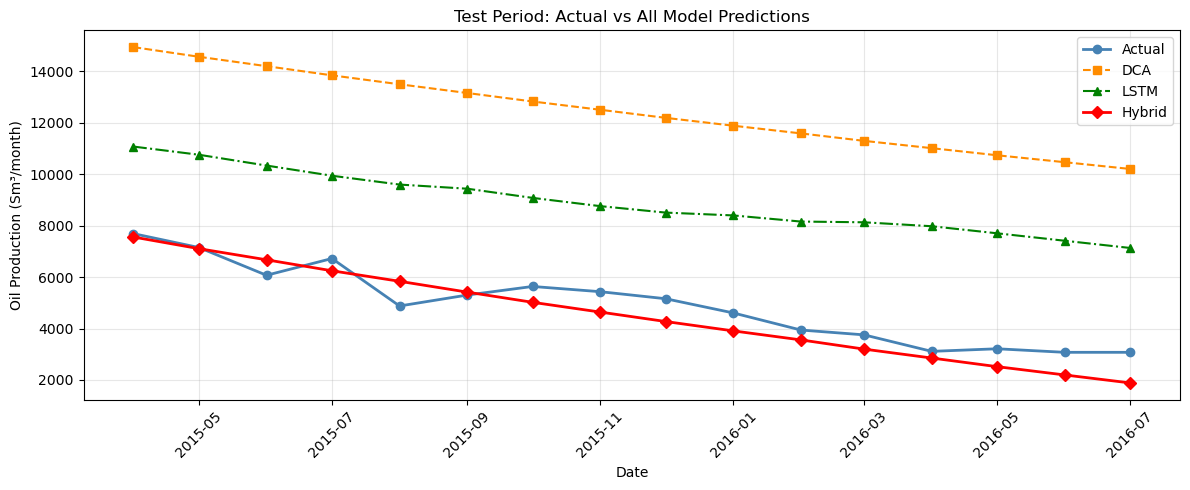

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Diagnostic: print actual vs predicted values side by side ────────────────
print("Month-by-month comparison (Test Period):")
print(f"{'Date':<12} {'Actual':>12} {'DCA':>12} {'LSTM':>12} {'Hybrid':>12}")
print("-" * 62)
for i in range(len(actual_te)):
    print(f"{str(pd.Timestamp(test_dates[i]))[:7]:<12} "
          f"{actual_te[i]:>12,.1f} "
          f"{dca_p[i]:>12,.1f} "
          f"{solo_lstm[i]:>12,.1f} "
          f"{hybrid_p[i]:>12,.1f}")

print()
print(f"Test actual mean : {actual_te.mean():,.2f} Sm³/month")
print(f"Test actual std  : {actual_te.std():,.2f} Sm³/month")
print(f"Naive mean pred  : {actual_te.mean():,.2f}  (baseline R² compares against this)")

# ── Plot actual vs all predictions ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates, actual_te,  marker='o', color='steelblue', lw=2,   label='Actual')
ax.plot(test_dates, dca_p,      marker='s', color='darkorange', lw=1.5, linestyle='--', label='DCA')
ax.plot(test_dates, solo_lstm,  marker='^', color='green',      lw=1.5, linestyle='-.', label='LSTM')
ax.plot(test_dates, hybrid_p,   marker='D', color='red',        lw=2,   label='Hybrid')
ax.set_title('Test Period: Actual vs All Model Predictions', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Oil Production (Sm³/month)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pipeline_outputs/fig_diagnostic_test_period.png', dpi=150, bbox_inches='tight')
plt.show()